# Extracting topographic metrics for the Southeast-Corinth from Copernicus 10 m

**Bodo Bookhagen**

**You will need to install the python interface for topotoolbox.**
```bash
conda activate DEMdata
pip install topotoolbox
```

Or if you already have installed this:
```bash
pip install --upgrade topotoolbox
```

We will mostly rely on topotoolbox - but other packages will provide similar results.

**NOTE: If you have limited computational capabilities (i.e., a small memory amount (<16 GB) on your laptop), use [COP10_EastCorinth_10m_epsg32634.tif](https://www.dropbox.com/scl/fi/52wg8f8iydke83m7jyni7/COP10_EastCorinth_10m_epsg32634.tif?rlkey=fz26ljjvuphbdyojq3isn7dva&st=dpuiziyc&dl=0)**


In [1]:
import numpy as np
import topotoolbox as tt3

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import os, copy
import geopandas as gpd
from scipy import stats
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

import copy

In [16]:
secorinth_dem_fn='./COP10_SoutheastCorinth_10m_epsg32634_nan_sinks.tif'
dem = tt3.read_tif(secorinth_dem_fn)

In [17]:
dem

name: COP10_SoutheastCorinth_10m_epsg32634_nan_sinks
        path: ./COP10_SoutheastCorinth_10m_epsg32634_nan_sinks.tif
        rows: 4504
        cols: 3941
        cellsize: 10.0
        bounds: BoundingBox(left=619163.4221093694, bottom=4178948.7007578127, right=658573.4221093694, top=4223988.700757813)
        transform: | 10.00, 0.00, 619163.42|
| 0.00,-10.00, 4223988.70|
| 0.00, 0.00, 1.00|
        coordinate system (Projected): EPSG:32634
        maximum z-value: 2373.413330078125
        minimum z-value: -3.496429681777954
        

In [18]:
dem.z

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4504, 3941), dtype=float32)

In [19]:
# set 0 to NaN if they exist in the DEM
#dem.z[dem.z == 0] = np.nan

Text(0, 0.5, 'UTM-Y')

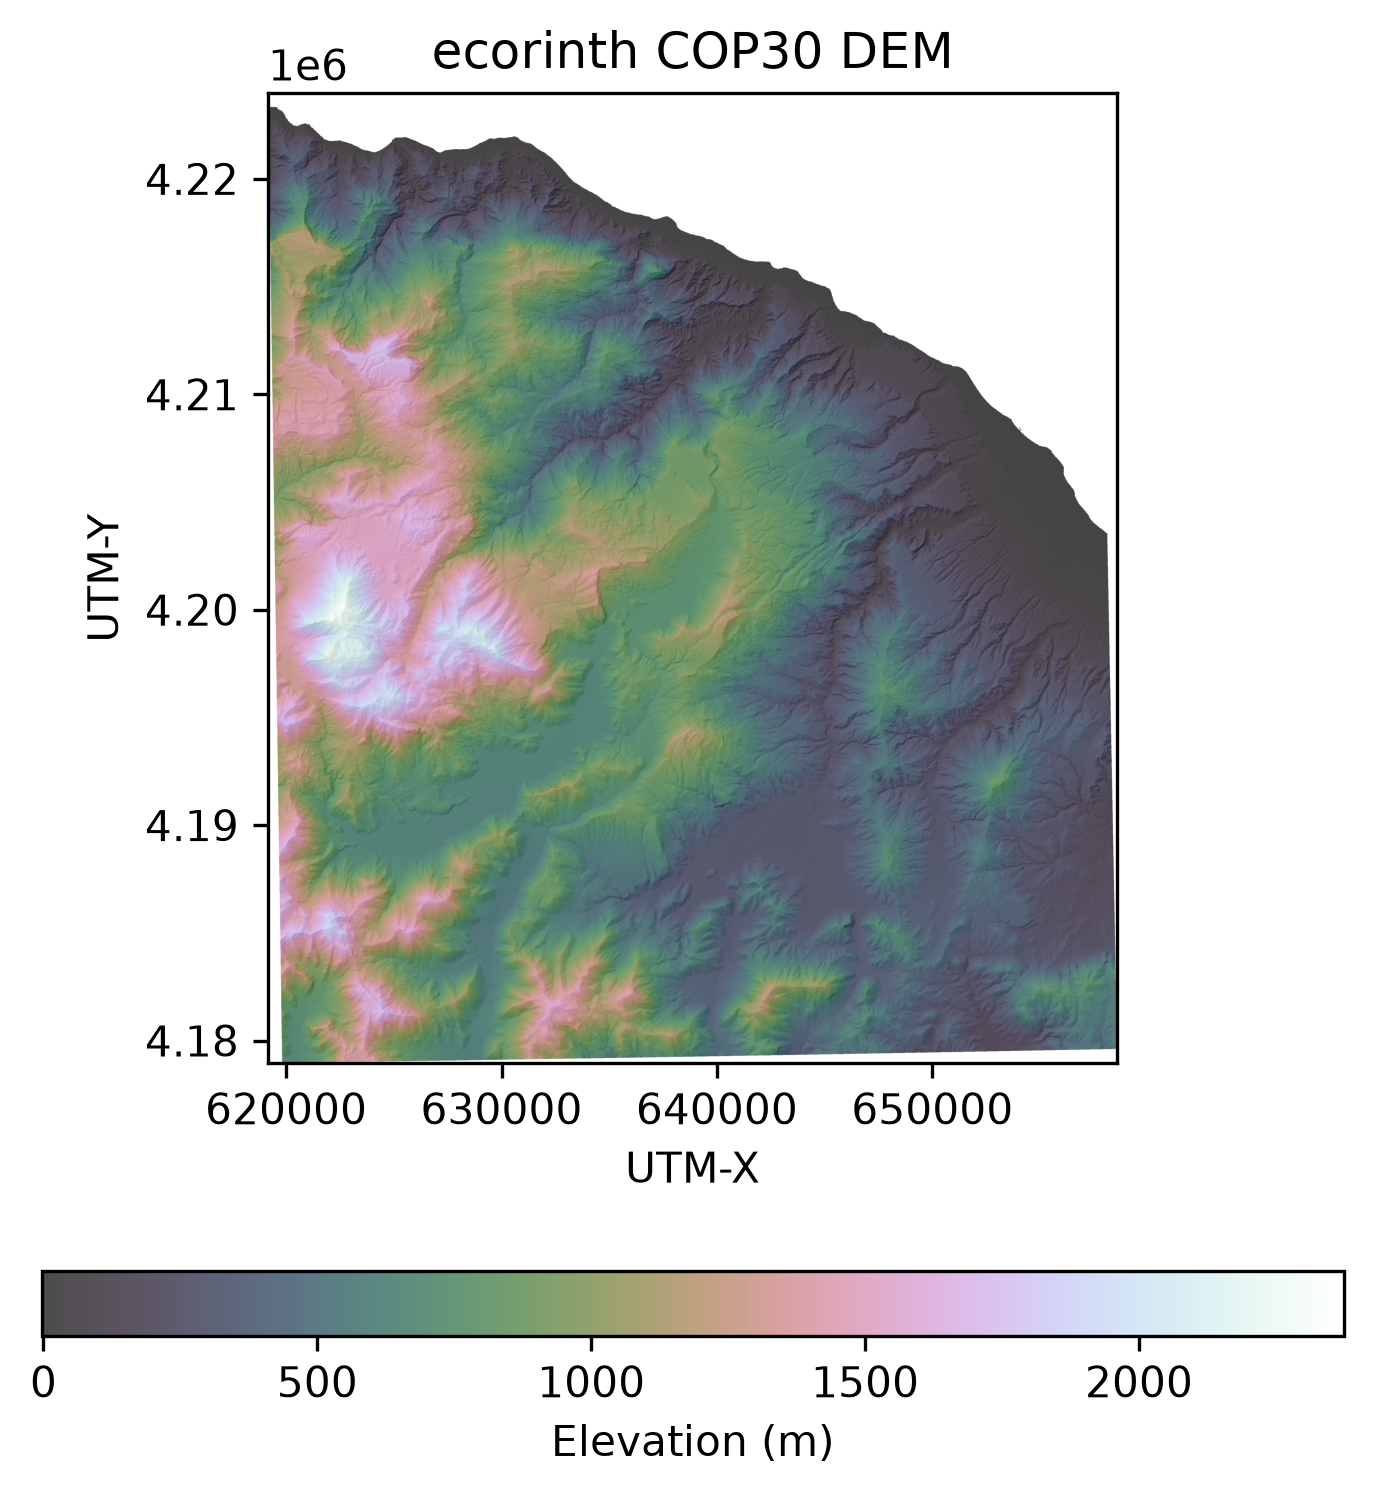

In [20]:
fig, ax = plt.subplots(figsize=(8,6), dpi=300)
plt.imshow(dem.hillshade(), extent=dem.extent, cmap='gray')
im0 = plt.imshow(dem, extent=dem.extent, cmap='cubehelix', alpha=0.7)
plt.colorbar(im0, label='Elevation (m)', orientation='horizontal', shrink=0.7)
plt.title('SE-corinth COP30 DEM')
plt.xlabel('UTM-X')
plt.ylabel('UTM-Y')

## Derive Flow properties

In [21]:
fd = tt3.FlowObject(dem)
acc = fd.flow_accumulation()

In [22]:
#Extract streams from flow accumulation network for network 
s = tt3.StreamObject(fd, threshold=0.1, units='km2')

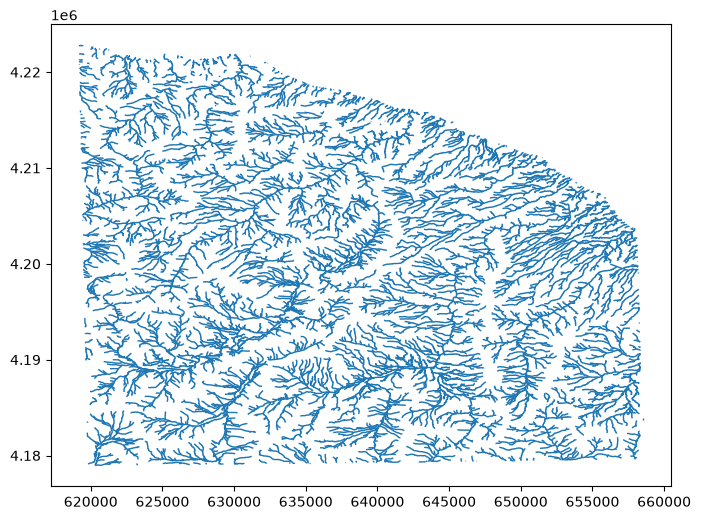

In [23]:
fig, ax = plt.subplots(figsize=(8,6))
s.plot(ax=ax, linewidth=1)
ax.autoscale_view()

In [24]:
# Extract Drainage Basins
D = fd.drainagebasins()

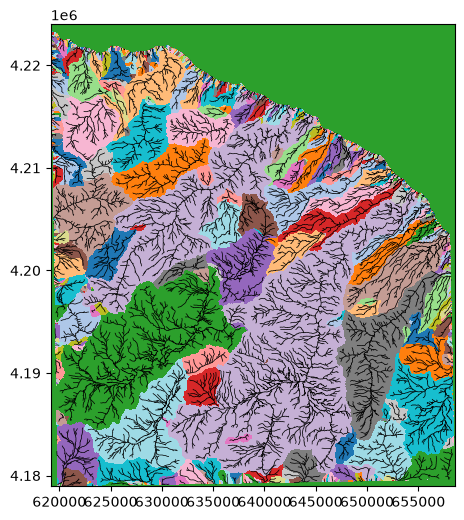

In [25]:
fig, ax = plt.subplots(figsize=(8,6))
D.shufflelabel().plot(cmap="tab20", ax=ax, interpolation="nearest")
s.plot(color='k', ax=ax, linewidth=0.5)
ax.autoscale_view()

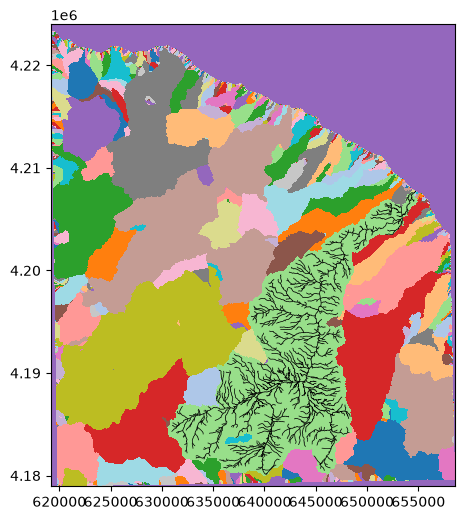

In [26]:
s_klargest = s.klargestconncomps()
fig, ax = plt.subplots(figsize=(8,6))
D.shufflelabel().plot(cmap="tab20", ax=ax, interpolation="nearest")
s_klargest.plot(color='k', ax=ax, linewidth=0.5)
ax.autoscale_view()

# Simple, first-order steepness index analysis with $\theta=0.45$

We can use existing and ready code to calculate the steepness index for every catchment using an average theta of 0.45. Note that a more detailed analysis would first require to find a region-averaged river curvature (theta).

In [27]:
tt3.StreamObject.ksn?

Signature: tt3.StreamObject.ksn(self, dem, a, impose=False, theta=0.45) -> 'np.ndarray'
Docstring:
Returns the normalized steepness index using a default concavity
index of 0.45.

Parameters
----------
dem: GridObject or np.ndarray
    Digital elevation model
a: GridObject
    Flow accumulation as returned by flowacc (GridObject)
impose: bool
    Minima imposition to avoid negative slopes (see imposemin
theta: float
    Concavity (default 0.45)

Returns
-------
k
    Normalized steepness index
File:      ~/miniconda3/envs/DEMdata/lib/python3.14t/site-packages/topotoolbox/stream_object.py
Type:      function

In [31]:
secorinth_ksn = s_klargest.ksn(dem=dem, a=acc, impose=True, theta=0.45)

In [32]:
secorinth_ksn

array([  0.        , 103.1024642 , 183.99772194, ...,  14.07446721,
         8.62784596,   9.9870229 ], shape=(56617,))

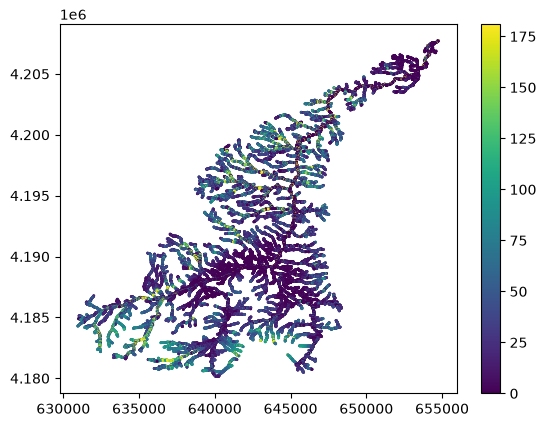

In [33]:
#very simple and fast plot
im=plt.scatter(s_klargest.x, s_klargest.y, s=1, c=secorinth_ksn, cmap='viridis', 
            vmin=np.nanpercentile(secorinth_ksn,2), 
            vmax=np.nanpercentile(secorinth_ksn, 98))
plt.colorbar(im)

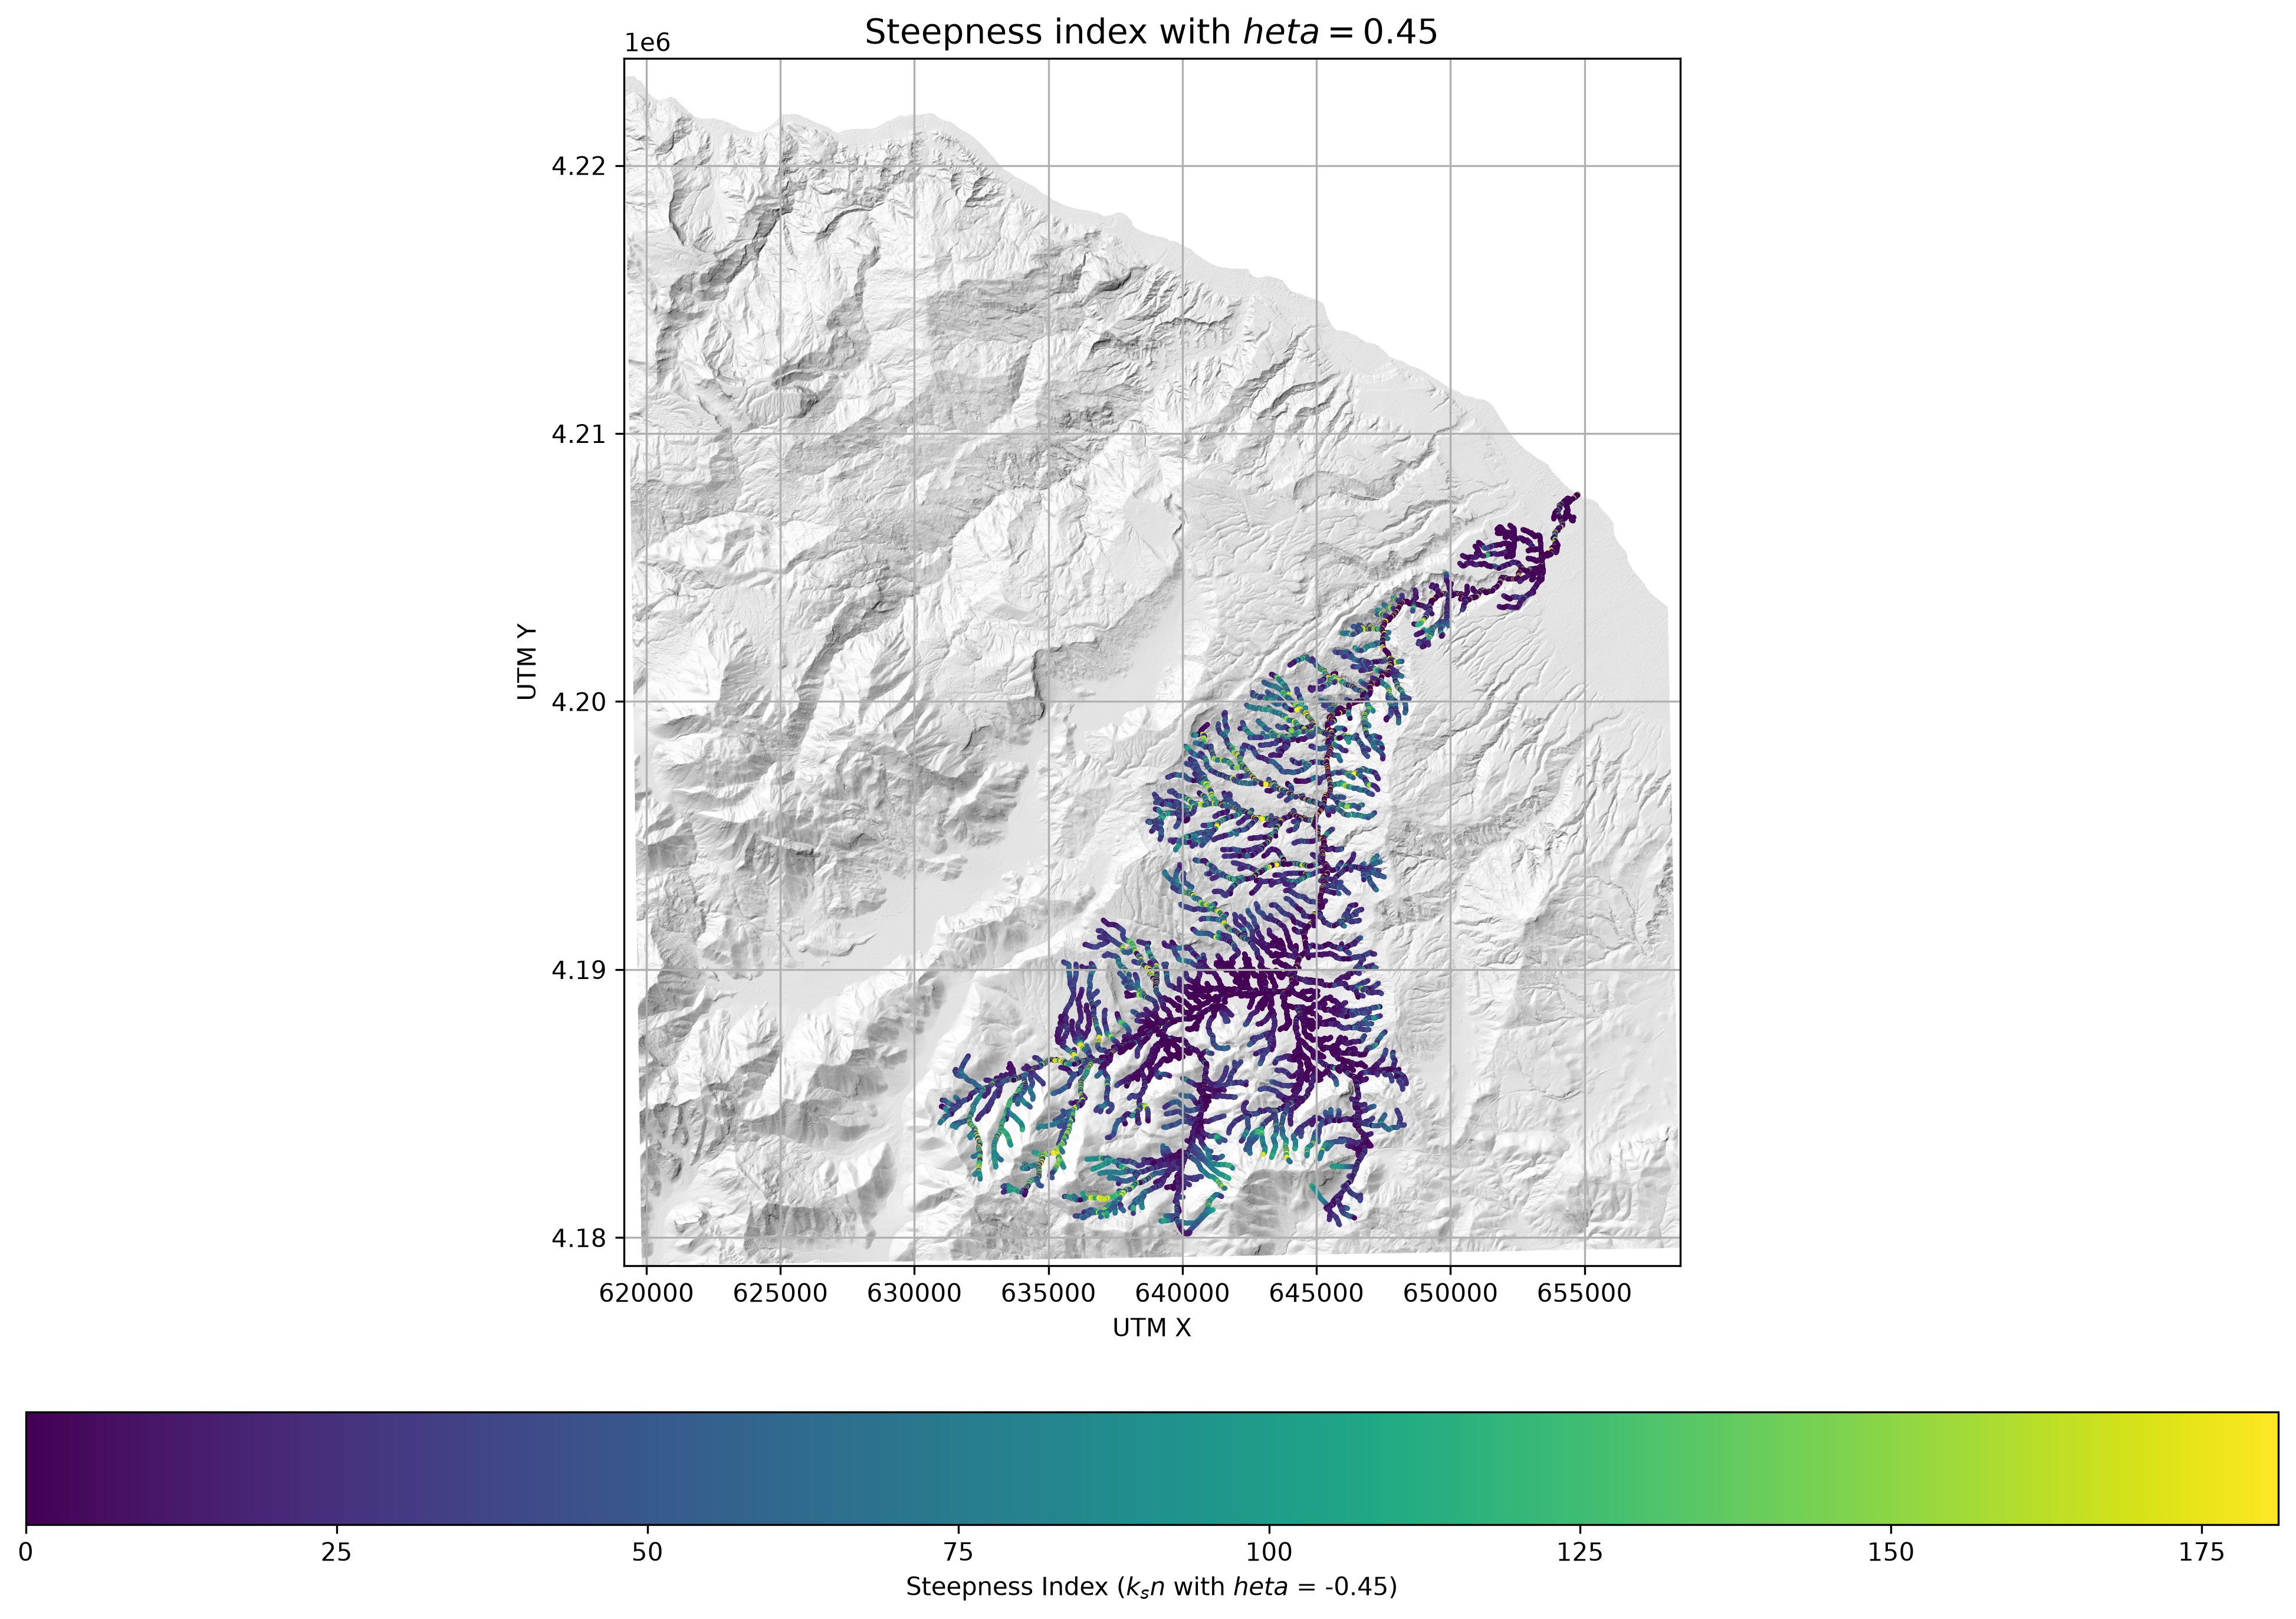

In [34]:
# More detailed plot (takes longer to generate)
fig, ax = plt.subplots(figsize=(16,9), dpi=300, layout='constrained')
fig.patch.set_alpha(0)
plt.grid('on')
plt.imshow(dem.hillshade(), extent=dem.extent, cmap='gray')
im=plt.scatter(s_klargest.x, s_klargest.y, s=1, c=secorinth_ksn, cmap='viridis', 
            vmin=np.nanpercentile(secorinth_ksn,2), 
            vmax=np.nanpercentile(secorinth_ksn, 98))

plt.colorbar(im, ax=ax, label='Steepness Index ($k_sn$ with $\theta$ = -0.45)', orientation='horizontal', shrink=0.8)
plt.title('Steepness index with $\theta=0.45$', size=14)
plt.xlabel('UTM X')
plt.ylabel('UTM Y')
ax.set_aspect('equal')
fig.savefig('secorinth_ksn.png')

# Single River Profile Analysis

Let's extract one river profile from the steep, northern section.

I am using QGIS to extract the coordinates.

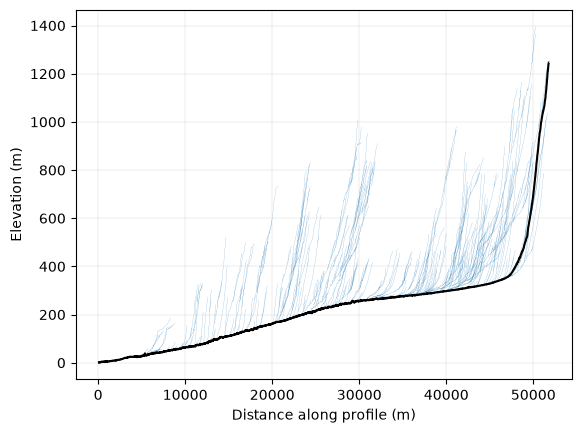

In [37]:
s_klargest.plotdz(dem, lw=0.1)
s_klargest.trunk().plotdz(dem, color='k')
plt.xlabel('Distance along profile (m)')
plt.ylabel('Elevation (m)')
plt.grid('-', color='gray', lw=0.1)